In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("Libraries successfully loaded.")

Libraries successfully loaded.


In [2]:
# Load dataset
file_path = 'Superstore Dataset Source (1).xlsx'
df = pd.read_excel(file_path, sheet_name='Orders')

# Display shape, column data types, and missing values
print("=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== DATA TYPES & NULL VALUES ===")
data_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Null Count': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(data_info)

# First 5 rows preview
df.head()

=== DATASET SHAPE ===
Rows: 9994, Columns: 21

=== DATA TYPES & NULL VALUES ===
                    Data Type  Null Count  Null Percentage (%)
Row ID                  int64           0                  0.0
Order ID                  str           0                  0.0
Order Date     datetime64[us]           0                  0.0
Ship Date      datetime64[us]           0                  0.0
Ship Mode                 str           0                  0.0
Customer ID               str           0                  0.0
Customer Name             str           0                  0.0
Segment                   str           0                  0.0
Country                   str           0                  0.0
City                      str           0                  0.0
State                     str           0                  0.0
Postal Code             int64           0                  0.0
Region                    str           0                  0.0
Product ID                str         

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Observation: The dataset contains 9,994 transaction records and 21 features with zero missing values. Essential features like Order Date and Ship Date are properly formatted as datetime objects, while numerical metrics (Sales, Quantity, Discount, Profit) are standard numeric types.

In [3]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

# Calculating summary statistics
stats_summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode': df[num_cols].mode().iloc[0],
    'Std Dev': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max()
})

print("=== DESCRIPTIVE STATISTICS ===")
stats_summary.round(2)

=== DESCRIPTIVE STATISTICS ===


,Mean,Median,Mode,Std Dev,Min,Max
Sales,229.86,54.49,12.96,623.25,0.44,22638.48
Quantity,3.79,3.00,3.00,2.23,1.00,14.00
Discount,0.16,0.20,0.00,0.21,0.00,0.80
Profit,28.66,8.67,0.00,234.26,-6599.98,8399.98


Observation:
Sales: The average order sale is $229.86, but the median is ($54.49), indicating a right-skewed distribution driven by large corporate purchases.

Profitability: Profit exhibits high variance (sigma = 234.26) ranging from severe losses (-6,599.98) to high margins (8,399.98).

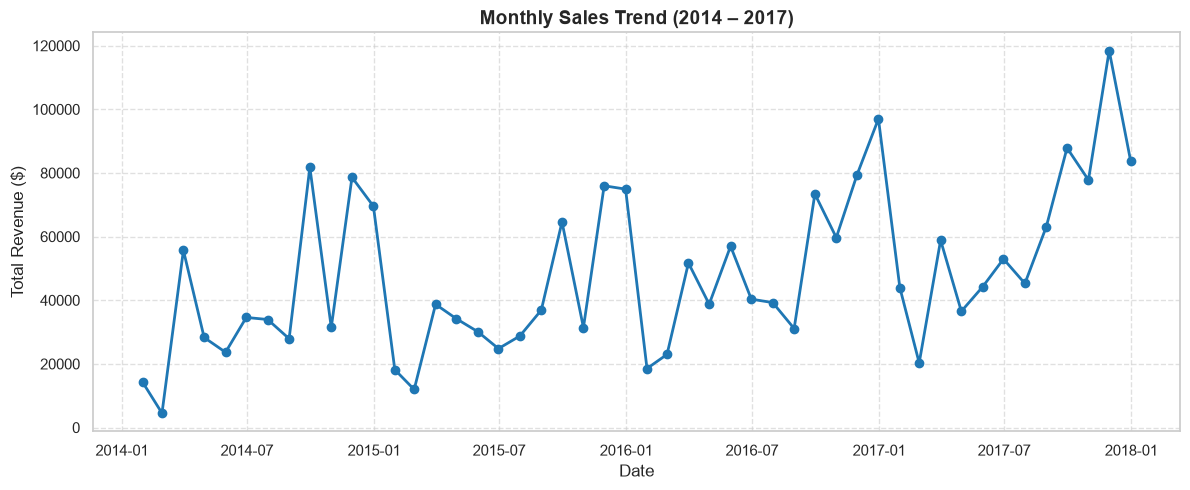

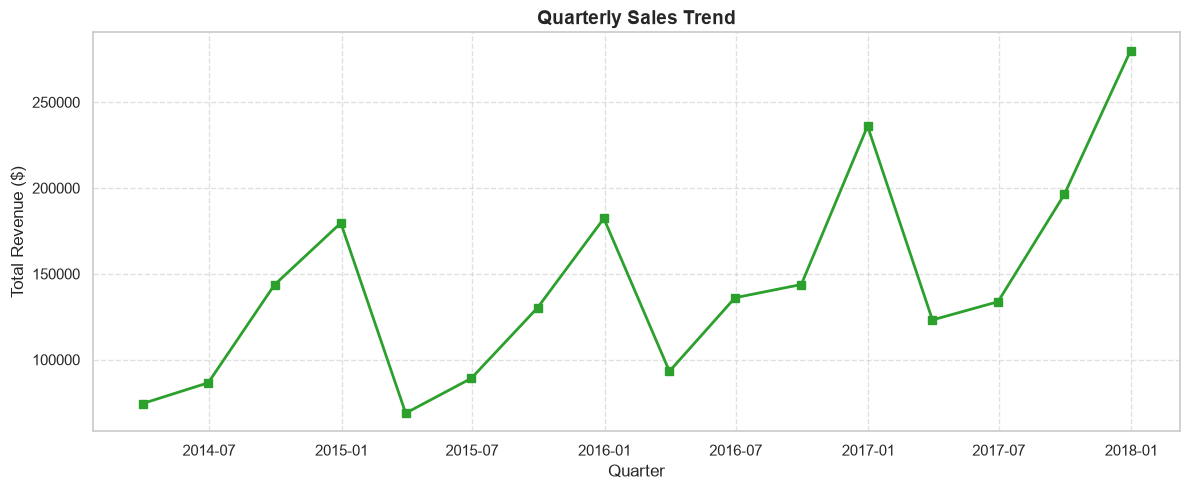

In [4]:
# Set Order Date as index for resampling
time_df = df.set_index('Order Date').sort_index()

# Resample monthly and quarterly sales
monthly_sales = time_df['Sales'].resample('ME').sum()
quarterly_sales = time_df['Sales'].resample('QE').sum()

# Plot Monthly Trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#1f77b4', linewidth=2)
plt.title('Monthly Sales Trend (2014 – 2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Quarterly Trend
plt.figure(figsize=(12, 5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='s', color='#2ca02c', linewidth=2)
plt.title('Quarterly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Observation: Clear seasonal peaks occur every Q4 (specifically November and December) due to holiday shopping cycles. Overall sales demonstrate strong year-over-year upward growth across all quarters.

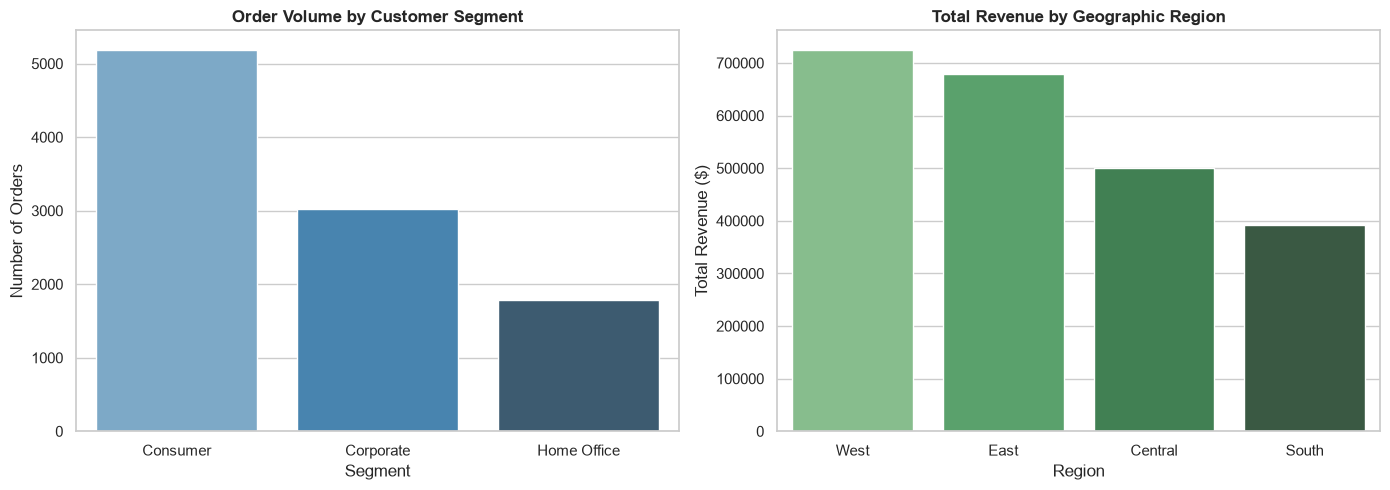

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer Segment Breakdown
sns.countplot(
    data=df, 
    x='Segment', 
    hue='Segment', 
    ax=axes[0], 
    palette='Blues_d', 
    legend=False
)
axes[0].set_title('Order Volume by Customer Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Orders')

# Revenue by Region
region_rev = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(
    x=region_rev.index, 
    y=region_rev.values, 
    hue=region_rev.index, 
    ax=axes[1], 
    palette='Greens_d', 
    legend=False
)
axes[1].set_title('Total Revenue by Geographic Region', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

Observation: The Consumer segment makes up over 50% of overall order volume. Regionally, the West and East territories drive the highest revenue output, whereas the South trails significantly.

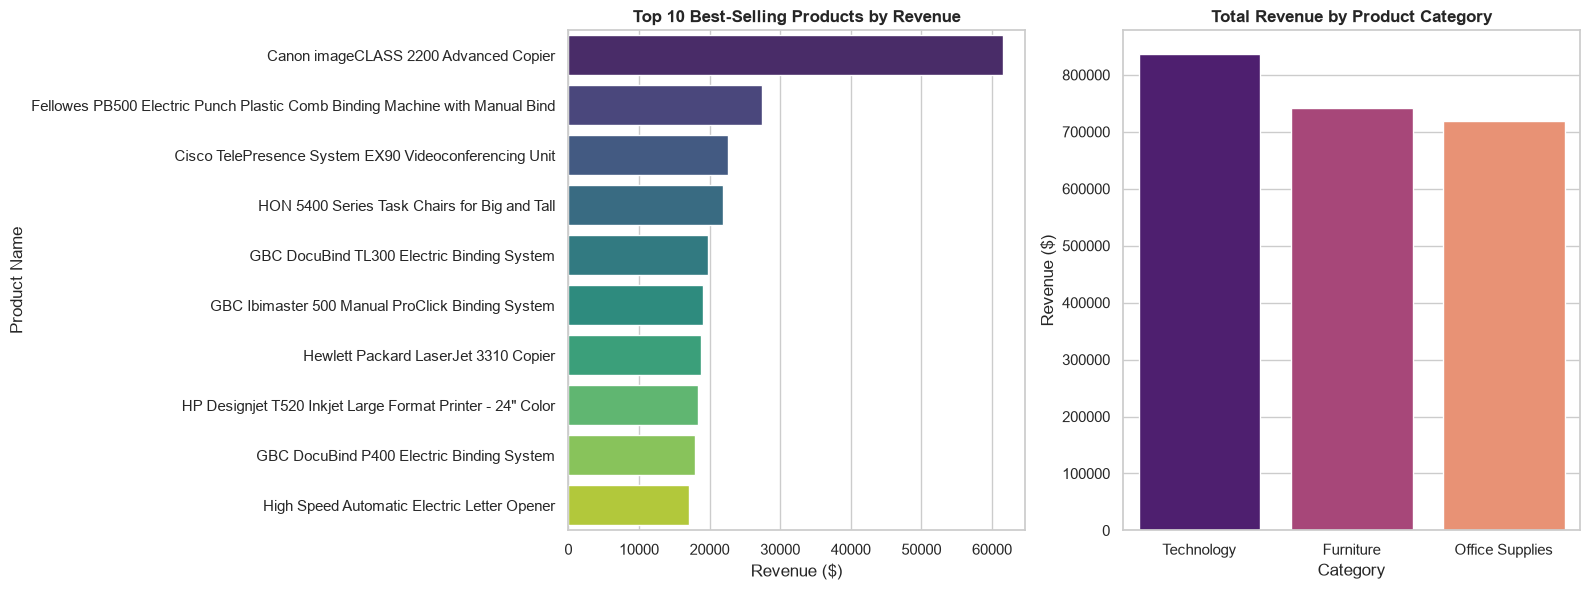

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Best-Selling Products
top_10_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
sns.barplot(
    x=top_10_products.values, 
    y=top_10_products.index, 
    hue=top_10_products.index, 
    ax=axes[0], 
    palette='viridis', 
    legend=False
)
axes[0].set_title('Top 10 Best-Selling Products by Revenue', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Revenue ($)')

# Revenue by Category
cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(
    x=cat_rev.index, 
    y=cat_rev.values, 
    hue=cat_rev.index, 
    ax=axes[1], 
    palette='magma', 
    legend=False
)
axes[1].set_title('Total Revenue by Product Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

Observation: Technology generates the highest overall revenue, with high-ticket items like copiers and phones topping individual product sales. Office Supplies yields high transaction volumes but lower per-unit revenue.

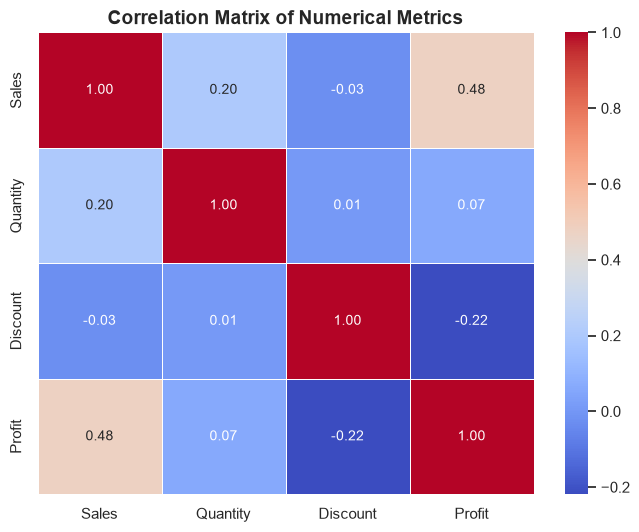

In [9]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[num_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Metrics', fontsize=14, fontweight='bold')
plt.show()

Observation: Profit has a weak positive correlation with Sales ($0.48$), but a notable negative relationship with Discount ($-0.22$). High discount rates severely degrade net profitability.

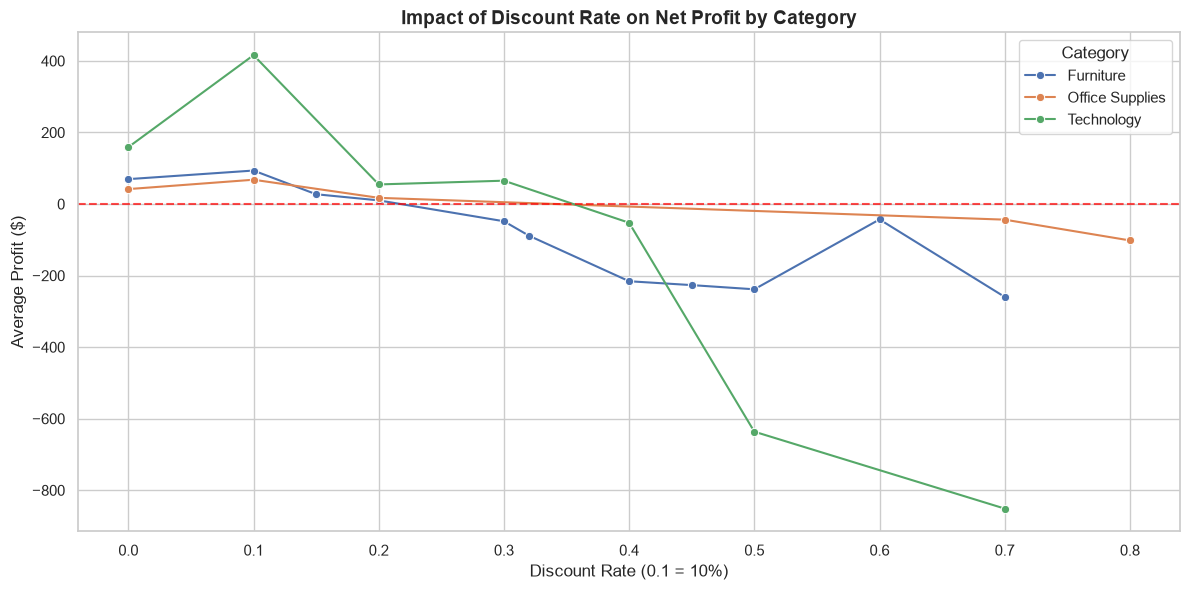

In [11]:
# Analyzing Profit Margin vs Discount Level across Categories
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df, 
    x='Discount', 
    y='Profit', 
    hue='Category', 
    errorbar=None, 
    marker='o'
)
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.title('Impact of Discount Rate on Net Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate (0.1 = 10%)')
plt.ylabel('Average Profit ($)')
plt.tight_layout()
plt.show()

Non-Obvious Insight: Discounts greater than 20% turn transactions unprofitable across all categories. Furniture suffers steepest losses, becoming highly negative at discount tiers above 30%.

## Conclusion & Actionable Business Recommendations

1. **Cap Discounting at 20% Max**: 
   Discounts exceeding 20% systematically generate negative profits across all categories. Restrict maximum promotional discount limits to safeguard net margins.

2. **Capitalize on Q4 Seasonality**:
   Sales peak sharply in Q4. Scale up inventory acquisition for high-margin Technology products starting in September to avoid stockouts during holiday surges.

3. **Re-evaluate Furniture Sub-categories**:
   Furniture yields high sales volume but poor profitability due to heavy shipping costs and discounting. Restructure pricing and vendor contracts specifically for Bookcases and Tables.